## Dataset 1: Hospital Admissions, Public Sector Outpatient Attendances and Day Surgery Counts

In [9]:
# Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.ticker import MaxNLocator

In [10]:
healthcare_facilities_df = pd.read_csv("C:/Users/tk_ko/Desktop/SGH/1. Hospital Admissions, Public Sector Outpatient Attendances And Day Surgery Counts.csv")

In [11]:
# Display the raw shape and the first 10 rows
print("Raw shape: ", healthcare_facilities_df.shape)
healthcare_facilities_df.head(10)

Raw shape:  (6216, 4)


,Healthcare Facilities,Admission Counts,Year,Month
0,Community Hospitals Admissions (Non-Public),na,1989,Sep
1,Psychiatric Hospitals Admissions (Non-Public),na,1993,Mar
2,Community Hospitals Admissions (Total),1609,2019,Jan
3,Polyclinics,435294,2016,Dec
4,Acute Hospitals Admissions (Public),na,1987,Jun
5,Acute Hospitals Admissions (Public),44184,2023,Aug
6,Polyclinics,478843,2017,Jun
7,Psychiatric Hospitals Admissions (Public),793,2010,Sep
8,Acute Hospitals Admissions (Public),na,1996,Oct
9,Specialist Outpatient Clinics,186011,1995,Nov


In [12]:
# Describe the info of each column
healthcare_facilities_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6216 entries, 0 to 6215
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Healthcare Facilities  6216 non-null   object
 1   Admission Counts       6216 non-null   object
 2   Year                   6216 non-null   int64 
 3   Month                  6216 non-null   object
dtypes: int64(1), object(3)
memory usage: 194.4+ KB


In [13]:
# Show all rows when printing value_counts as a Series
pd.options.display.max_rows = None

# Exploring range of unique values to check if there are other unexpected values besides 'na'
healthcare_facilities_df['Admission Counts'].value_counts(dropna=False)

Admission Counts
na        2268
0          255
707         10
791          9
697          9
692          9
755          8
797          8
599          8
578          7
737          7
632          7
672          7
781          7
763          7
665          7
733          7
732          7
787          6
607          6
794          6
790          6
630          6
801          6
757          6
793          6
741          6
803          6
879          5
655          5
690          5
762          5
696          5
824          5
639          5
626          5
719          5
811          5
786          5
640          5
678          5
795          5
767          5
689          5
738          5
805          5
724          5
694          5
638          5
761          5
754          5
749          5
865          4
651          4
617          4
667          4
730          4
771          4
745          4
22           4
728          4
538          4
780          4
815          4
646          4
627     

In [14]:
# Find rows where Admission Counts is 'na', removing leading and trailing spaces and checking whether the cleaned value is exactly 'na'
healthcare_na_mask = healthcare_facilities_df['Admission Counts'].astype(str).str.strip().eq('na')
healthcare_na_rows = healthcare_facilities_df[healthcare_na_mask]

# Confirm that na_rows only contain 'na'
healthcare_na_rows['Admission Counts'].value_counts(dropna=False)

Admission Counts
na    2268
Name: count, dtype: int64

In [15]:
# Keep only non-na rows
healthcare_facilities_df = healthcare_facilities_df[~healthcare_na_mask]

# Confirm there are no more 'na' rows
healthcare_facilities_df['Admission Counts'].astype(str).str.strip().eq('na').sum()

np.int64(0)

In [16]:
# Convert Admission Counts from object to numeric
healthcare_facilities_df['Admission Counts'] = pd.to_numeric(healthcare_facilities_df['Admission Counts'])

In [17]:
# Sanity check on Admission Counts column to check the distribution of values
healthcare_facilities_df['Admission Counts'].describe().T

count      3948.000000
mean      92139.220111
std      132747.562852
min           0.000000
25%         792.750000
50%       37385.500000
75%       97916.500000
max      627174.000000
Name: Admission Counts, dtype: float64

Admission Counts has a large standard deviation that is higher than mean. It has an extreme maximum value of 627,174, which is still a possible value for number of admissions in a year.

In [18]:
# Check for nulls
healthcare_facilities_df.isnull().sum()

Healthcare Facilities    0
Admission Counts         0
Year                     0
Month                    0
dtype: int64

In [19]:
# Check for duplicate rows
healthcare_duplicates = healthcare_facilities_df.duplicated()
healthcare_facilities_df[healthcare_duplicates]

,Healthcare Facilities,Admission Counts,Year,Month


In [20]:
# Exploring the range of values in the remaining columns to check unexpected values
print(healthcare_facilities_df['Healthcare Facilities'].value_counts(), '\n')
print(healthcare_facilities_df['Year'].value_counts().sort_index(), '\n')
print(healthcare_facilities_df['Month'].value_counts().sort_index(), '\n')

Healthcare Facilities
Polyclinics                                      444
Specialist Outpatient Clinics                    444
Dental Clinics                                   444
Accident & Emergency Departments                 444
Day Surgeries                                    228
Community Hospitals Admissions (Total)           216
Acute Hospitals Admissions (Public)              216
Psychiatric Hospitals Admissions (Public)        216
Community Hospitals Admissions (Non-Public)      216
Acute Hospitals Admissions (Total)               216
Acute Hospitals Admissions (Non-Public)          216
Psychiatric Hospitals Admissions (Total)         216
Community Hospitals Admissions (Public)          216
Psychiatric Hospitals Admissions (Non-Public)    216
Name: count, dtype: int64 

Year
1987     48
1988     48
1989     48
1990     48
1991     48
1992     48
1993     48
1994     48
1995     48
1996     48
1997     48
1998     48
1999     48
2000     48
2001     48
2002     48
2003     48

After 'na' values are removed, the dataset has largely uniform records across healthcare facility types, year and month. There is a greater skew of records towards Polyclinics, Specialist Outpatient Clinics and Years 2007-2023.

## Visualization 1

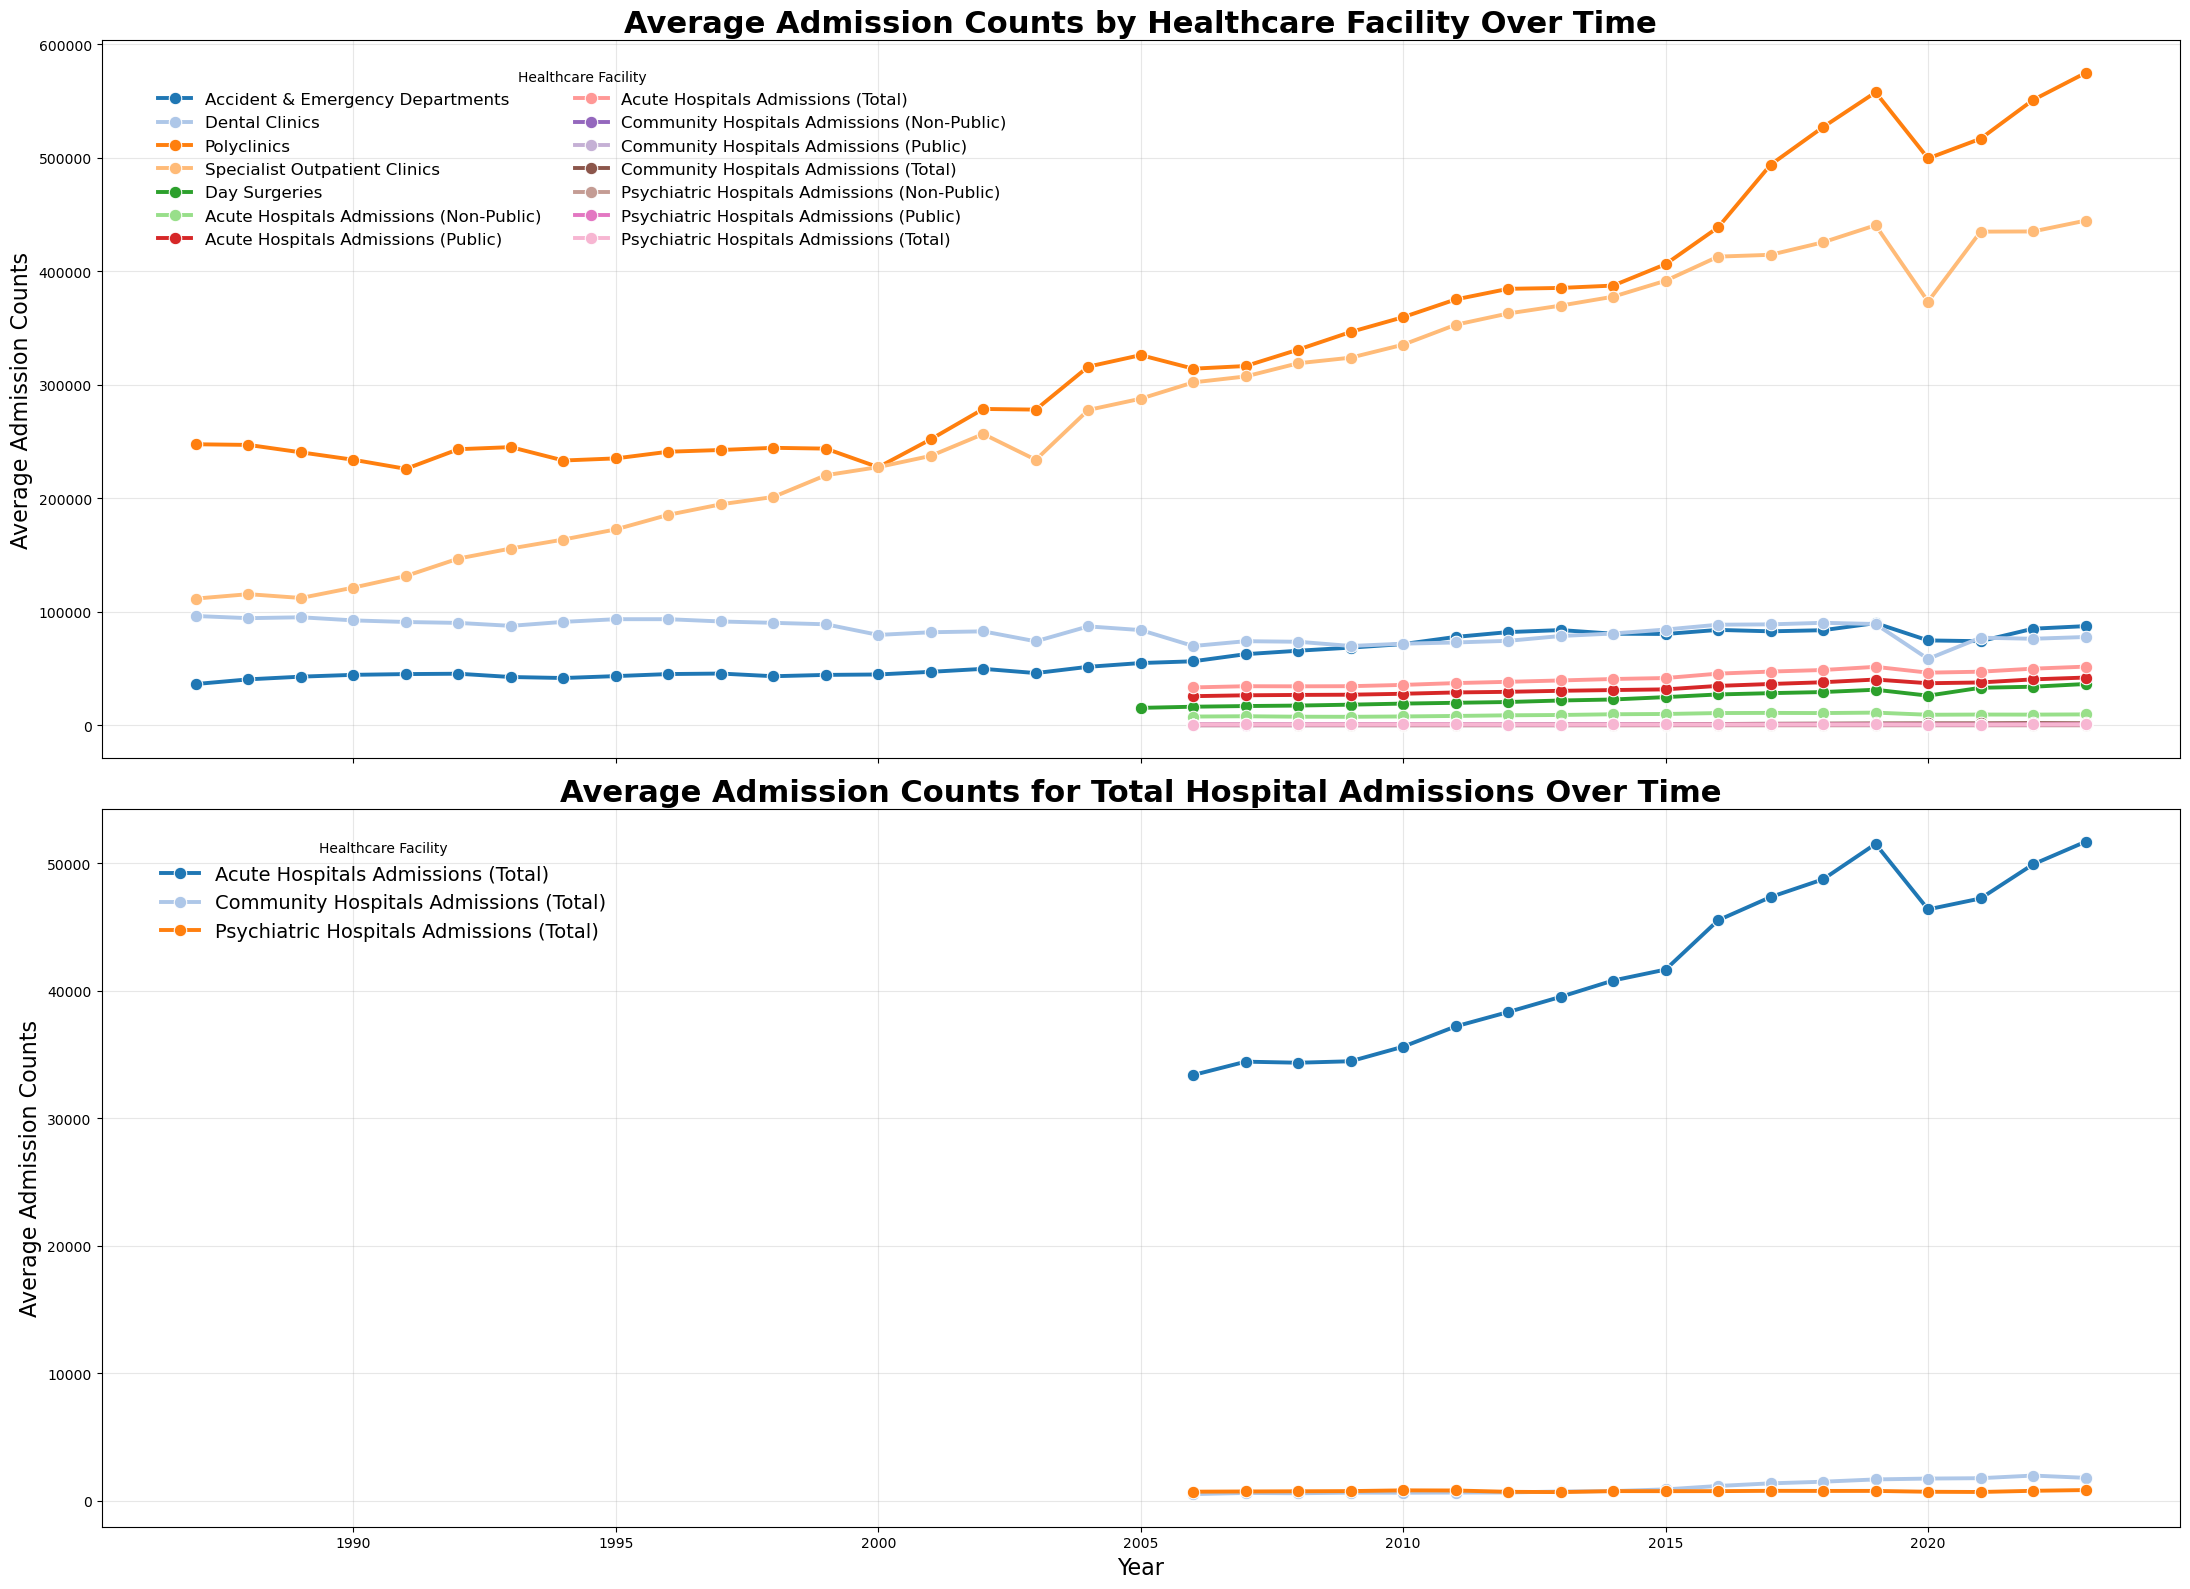

In [30]:
# Preparing filtered data before visualization
yearly_admissions = (
    healthcare_facilities_df
    .dropna(subset=['Admission Counts'])
    .groupby(['Year', 'Healthcare Facilities'], as_index=False)['Admission Counts']
    .mean()
)

total_facilities = [
    'Acute Hospitals Admissions (Total)',
    'Psychiatric Hospitals Admissions (Total)',
    'Community Hospitals Admissions (Total)'
]

yearly_admissions_total = yearly_admissions[
    yearly_admissions['Healthcare Facilities'].isin(total_facilities)
]

# Create two subplots stacked vertically (2 rows, 1 column)
fig, axes = plt.subplots(2, 1, figsize=(22, 16), sharex=True)

# Chart 1: Average Admission Counts by Healthcare Facility Over Time
# Explore whether outpatient faciltiies like polyclinics and specialist outpatient clinics receive high admission volumes, and how this trends over time
sns.lineplot(
    data=yearly_admissions,
    x='Year',
    y='Admission Counts',
    hue='Healthcare Facilities',
    palette=sns.color_palette('tab20', n_colors=yearly_admissions['Healthcare Facilities'].nunique()),
    marker='o',
    markersize=9,
    linewidth=2.8,
    ax=axes[0]
)
axes[0].set_title(
    'Average Admission Counts by Healthcare Facility Over Time',
    fontsize=22, fontweight='bold'
)
axes[0].set_xlabel('Year', fontsize=16)
axes[0].set_ylabel('Average Admission Counts', fontsize=16)

sns.move_legend(
    axes[0],
    loc="upper left",
    bbox_to_anchor=(0.02, 0.98),
    ncol=2,              # 2 columns to keep it compact
    title="Healthcare Facility",
    frameon=False,
    fontsize=12
)

axes[0].grid(alpha=0.3)

# Chart 2: Average Admission Counts for Total Hospital Admissions Over Time
# Specific chart for inpatient hospitals for greater clarity of the trends as the lines are unclear in the first chart
sns.lineplot(
    data=yearly_admissions_total,
    x='Year',
    y='Admission Counts',
    hue='Healthcare Facilities',
    palette=sns.color_palette('tab20', n_colors=yearly_admissions_total['Healthcare Facilities'].nunique()),
    marker='o',
    markersize=9,
    linewidth=2.8,
    ax=axes[1]
)
axes[1].set_title(
    'Average Admission Counts for Total Hospital Admissions Over Time',
    fontsize=22, fontweight='bold'
)
axes[1].set_xlabel('Year', fontsize=16)
axes[1].set_ylabel('Average Admission Counts', fontsize=16)

sns.move_legend(
    axes[1],
    loc="upper left",
    bbox_to_anchor=(0.02, 0.98),
    ncol=1,
    title="Healthcare Facility",
    frameon=False,
    fontsize=14
)

axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

Outpatient clinics such as Polyclinics and Specialist Outpatient Clinics have the largest average volume of admissions, showing the strongest growth from 2015 to 2019. Hospital admissions (Acute, Community, Psychiatric Hospitals) climb much more gently, with Acute Hospitals having the highest average among hospital types.

Polyclinics, Specialist Outpatient Clinics and Acute Hospitals experienced a sharp drop in 2020, which likely reflects the impact of COVID-19 lockdowns and reduced patient willingness to seek care due to concerns of exposure.

## Dataset 2: Hospital Admission Rate by Gender and Age

In [32]:
hospital_admissions_df = pd.read_csv("C:/Users/tk_ko/Desktop/SGH/2. Hospital Admission Rate by Gender and Age.csv")

In [33]:
# Display the raw shape and the first 10 rows
print("Raw shape: ", hospital_admissions_df.shape)
hospital_admissions_df.head(10)

Raw shape:  (324, 5)


,Age Group,Gender,Hospital Type,Year,Admission Rate (Per 1000 Resident)
0,65 Years Old & Above,Female,Acute Hospitals,2020,274.6
1,0 - 14 Years Old,Male,Psychiatric Hospitals,2011,0.1
2,15 - 64 Years Old,Male,Community Hospitals,2014,0.6
3,0 - 14 Years Old,Female,Acute Hospitals,2009,84.9
4,0 - 14 Years Old,Female,Community Hospitals,2013,0
5,15 - 64 Years Old,Male,Acute Hospitals,2011,65.4
6,15 - 64 Years Old,Male,Acute Hospitals,2012,66.7
7,65 Years Old & Above,Male,Community Hospitals,2017,23.4
8,0 - 14 Years Old,Male,Psychiatric Hospitals,2013,0.2
9,0 - 14 Years Old,Male,Acute Hospitals,2016,142.1


In [22]:
# Describe the info of each column
hospital_admissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 5 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Age Group                           324 non-null    object
 1   Gender                              324 non-null    object
 2   Hospital Type                       324 non-null    object
 3   Year                                324 non-null    int64 
 4   Admission Rate (Per 1000 Resident)  324 non-null    object
dtypes: int64(1), object(4)
memory usage: 12.8+ KB


In [34]:
# Exploring range of unique values to check if there are unexpected values
# '-' is the only non-numeric value to remove
hospital_admissions_df['Admission Rate (Per 1000 Resident)'].value_counts(dropna=False)

Admission Rate (Per 1000 Resident)
0.1      26
0        20
0.2      14
-         9
0.5       8
1.9       7
1.7       7
0.4       7
2         6
1.5       6
1.8       6
0.6       6
3.3       5
3.2       4
2.1       4
1.3       4
1.6       4
1.4       3
1.1       3
2.7       3
2.5       3
1         3
2.2       3
2.6       2
2.3       2
2.8       2
3.5       2
3         2
26.7      2
0.7       2
14.9      2
109.4     2
24.8      2
16.4      2
2.9       2
14.4      2
23.4      2
347.6     2
302.6     1
18        1
368.2     1
86.1      1
75.7      1
101.2     1
0.9       1
16        1
99.2      1
140.4     1
70        1
26.2      1
304       1
13.6      1
3.1       1
25.6      1
16.8      1
295.7     1
313.8     1
81.4      1
308       1
71.5      1
86.6      1
23        1
15.6      1
25.5      1
274.6     1
299.9     1
299.8     1
62.7      1
63.9      1
78.3      1
75        1
139.5     1
110.9     1
371.8     1
14.1      1
128.5     1
369.1     1
121.5     1
127       1
80.1      1
77.2 

In [57]:
# Find rows where Admission Rate is '-', removing leading and trailing spaces and checking whether the cleaned value is exactly '-'
hospital_dash_mask = hospital_admissions_df['Admission Rate (Per 1000 Resident)'].astype(str).str.strip().eq('-')
hospital_dash_rows = hospital_admissions_df[hospital_dash_mask]

# Confirm that hospital_dash_rows only contain '-'
hospital_dash_rows['Admission Rate (Per 1000 Resident)'].value_counts(dropna=False)

Admission Rate (Per 1000 Resident)
-    9
Name: count, dtype: int64

In [59]:
# Keep only non-dash rows
hospital_admissions_df = hospital_admissions_df[~hospital_dash_mask]

# Confirm there are no more '-' rows
hospital_admissions_df['Admission Rate (Per 1000 Resident)'].astype(str).str.strip().eq('-').sum()

np.int64(0)

In [62]:
# Convert Admission Rate from object to numeric
hospital_admissions_df['Admission Rate (Per 1000 Resident)'] = pd.to_numeric(hospital_admissions_df['Admission Rate (Per 1000 Resident)'])

In [63]:
# Sanity check on Admission Counts column to check the distribution of values using describe()
hospital_admissions_df['Admission Rate (Per 1000 Resident)'].describe().T

count    315.000000
mean      61.988571
std      103.434386
min        0.000000
25%        0.600000
50%        3.000000
75%       84.600000
max      376.500000
Name: Admission Rate (Per 1000 Resident), dtype: float64

The Admission Rate (Per 1000 Resident) column is right-skewed, with most values clustered at the lower-end of the distribution. The higher-than-mean standard deviation suggests that there is a small number of extreme admission rates that pull up the mean, but the rest of the data is closer to zero.

In [64]:
# Check for nulls
hospital_admissions_df.isnull().sum()

Age Group                             0
Gender                                0
Hospital Type                         0
Year                                  0
Admission Rate (Per 1000 Resident)    0
dtype: int64

In [66]:
# Check for duplicate rows
hospital_duplicates = hospital_admissions_df.duplicated()
hospital_admissions_df[hospital_duplicates]

,Age Group,Gender,Hospital Type,Year,Admission Rate (Per 1000 Resident)


In [32]:
# Exploring the range of values in the remaining columns to check unexpected values
print(hospital_admissions_df['Age Group'].value_counts(), '\n')
print(hospital_admissions_df['Gender'].value_counts(), '\n')
print(hospital_admissions_df['Hospital Type'].value_counts(), '\n')
print(hospital_admissions_df['Year'].value_counts(), '\n')

Age Group
65 Years Old & Above    108
0 - 14 Years Old        108
15 - 64 Years Old       108
Name: count, dtype: int64 

Gender
Female    162
Male      162
Name: count, dtype: int64 

Hospital Type
Acute Hospitals          108
Psychiatric Hospitals    108
Community Hospitals      108
Name: count, dtype: int64 

Year
2020    18
2011    18
2010    18
2023    18
2022    18
2019    18
2006    18
2015    18
2018    18
2008    18
2007    18
2016    18
2017    18
2012    18
2013    18
2009    18
2014    18
2021    18
Name: count, dtype: int64 



The Hospital Admissions dataset is perfectly uniform across all columns. Age Group, Gender, Hospital Type, Year have equal number of records with no skew. This means that any pattern found from the data reflect genuine differences and are not biased from unequal gender or age group.

## Visualization 2

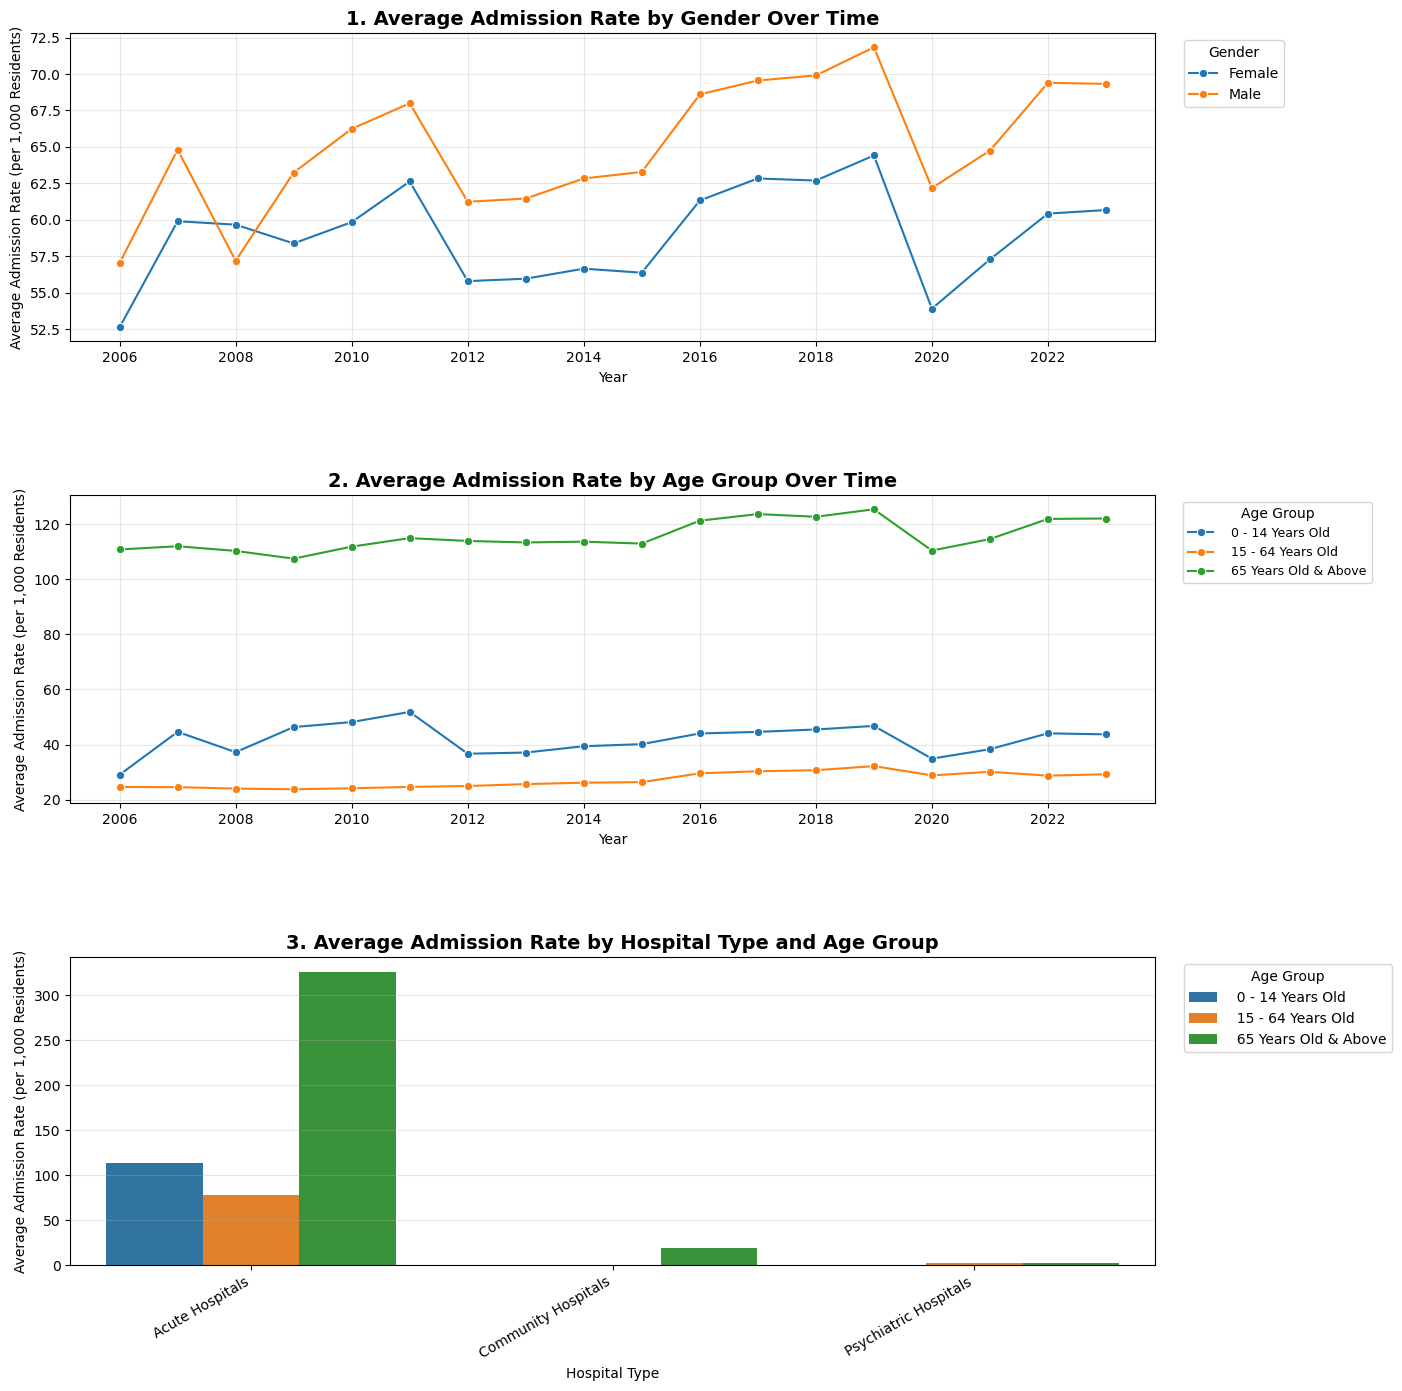

In [99]:
fig, axes = plt.subplots(3, 1, figsize=(14, 16))

# Chart 1: Admission Rate by Gender Over Time
# Observe any trends in healthcare demand that is gender-specific, or if there are any significant shifts that communicate demand changes
gender_rate_by_year = (
    hospital_admissions_df
    .groupby(['Year', 'Gender'], as_index=False)['Admission Rate (Per 1000 Resident)']
    .mean()
)

sns.lineplot(
    data=gender_rate_by_year,
    x='Year',
    y='Admission Rate (Per 1000 Resident)',
    hue='Gender',
    marker='o',
    ax=axes[0]
)
axes[0].set_title('1. Average Admission Rate by Gender Over Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Average Admission Rate (per 1,000 Residents)')
axes[0].legend(title='Gender', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[0].grid(alpha=0.3)

# Chart 2: Admission Rate by Age Group Over Time
# Age is the strongest driver of admission rates
# From this, we are able to see which age segments generate the highest burden and whether rates change within groups over time
age_rate_by_year = (
    hospital_admissions_df
    .groupby(['Year', 'Age Group'], as_index=False)['Admission Rate (Per 1000 Resident)']
    .mean()
)

sns.lineplot(
    data=age_rate_by_year,
    x='Year',
    y='Admission Rate (Per 1000 Resident)',
    hue='Age Group',
    marker='o',
    ax=axes[1]
)
axes[1].set_title('2. Average Admission Rate by Age Group Over Time', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average Admission Rate (per 1,000 Residents)')
axes[1].legend(title='Age Group', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[1].grid(alpha=0.3)

# Chart 3: Admission Rate by Hospital Type and Age Group
# Hospital utilization differs more strongly by age than by gender, espcailly when comparing acute, community and psychiatric settings
hospital_age_rate = (
    hospital_admissions_df
    .groupby(['Hospital Type', 'Age Group'], as_index=False)['Admission Rate (Per 1000 Resident)']
    .mean()
)

sns.barplot(
    data=hospital_age_rate,
    x='Hospital Type',
    y='Admission Rate (Per 1000 Resident)',
    hue='Age Group',
    ax=axes[2]
)
axes[2].set_title('3. Average Admission Rate by Hospital Type and Age Group', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Hospital Type')
axes[2].set_ylabel('Average Admission Rate (per 1,000 Residents)')
axes[2].tick_params(axis='x', rotation=30)
for label in axes[2].get_xticklabels():
    label.set_ha('right')
axes[2].legend(title='Age Group', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[2].grid(alpha=0.3, axis='y')

plt.subplots_adjust(hspace=0.5)
plt.show()

**Gender**: Males consistently show higher average admission rates than Females across every year, with the two genders also moving roughly in parallel, suggesting that the gender gap in hospital admissions has remained stable over time. This consistent gap suggests higher healthcare usage among Males relative to Females.

**Age**: 65 years old & above have consistently the highest average admission rates, with the gap between the other two age groups (0-14 years and 15-64 years) remaining stable across the years. As the population continues to age, there will be implications for long-term healthcare capacity planning.

**Hospital Type & Age**: Acute Hospitals have the highest average admission rates, with 65 years old & above at the highest  more than 4 times higher than the 15-64 years old. Community Hospitals are also almost exclusive to the elderly, which is consistent with their typical role of serving elderly patients recovering from acute conditions. Notably, 15-64 years old admit into Psychiatric Hospitals more than the elderly.

## Dataset 3: Prevalence of Health Indicators for SG adults

In [35]:
risk_factor_df = pd.read_excel("C:/Users/tk_ko/Desktop/SGH/3. Prevalence of Health Indicators for SG adults.xlsx", 
                               sheet_name = '3. Prevalence of Health Indicat')

In [36]:
# Display the raw shape and the first 10 rows
print("Raw shape: ", risk_factor_df.shape)
risk_factor_df.head(10)

Raw shape:  (216, 4)


,Risk Factor,Gender Category,Year,Proportion
0,Diabetes Mellitus,Female,2021,na
1,Obese,Total,2022,11.6
2,Daily Smoking,Male,2017,20.6
3,Binge Drinking,Male,2019,14.9
4,Sufficient Total Physical Activity,Male,2013,82.5
5,Hyperlipidaemia,Total,2017,35.5
6,Hyperlipidaemia,Male,2017,42.8
7,Sufficient Total Physical Activity,Total,2010,na
8,Daily Smoking,Male,2022,16
9,Obese,Male,2010,11.7


In [37]:
# Describe the info of each column
risk_factor_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Risk Factor      216 non-null    object
 1   Gender Category  216 non-null    object
 2   Year             216 non-null    int64 
 3   Proportion       216 non-null    object
dtypes: int64(1), object(3)
memory usage: 6.9+ KB


In [38]:
# Exploring range of unique values to check if there are unexpected values
# 'na' is the only non-numeric value to remove
risk_factor_df['Proportion'].value_counts(dropna=False)

Proportion
na      75
13.1     4
8.8      3
8.6      3
10.5     3
9.4      3
5.7      2
3.3      2
9.2      2
10.3     2
30.2     2
7.4      2
28.8     2
10.6     2
10.2     2
84.6     2
36.2     2
35.5     2
42.8     2
10       1
35.1     1
24.2     1
25.7     1
33.5     1
9.5      1
28.5     1
7.8      1
44       1
8        1
8.4      1
20.7     1
3.8      1
31.9     1
9.6      1
22       1
27.5     1
10.4     1
9.7      1
27.9     1
10.7     1
13.8     1
4.7      1
2.3      1
76       1
23       1
6.4      1
30.8     1
24.6     1
23.1     1
76.6     1
19.8     1
35.8     1
4.2      1
83.5     1
11.9     1
79.5     1
20.6     1
7        1
14.9     1
3.4      1
85.6     1
2.2      1
85.7     1
78.1     1
82.5     1
80.7     1
37       1
14.6     1
4.3      1
9.3      1
74.9     1
29.8     1
7.1      1
74.1     1
13.7     1
23.6     1
26.2     1
3.6      1
39.1     1
21.7     1
3.2      1
23.9     1
17.8     1
19.2     1
10.1     1
78.5     1
17       1
76.7     1
80       1
15.7     1

In [39]:
# Find rows where Proportion is 'na', removing leading and trailing spaces and checking whether the cleaned value is exactly 'na'
risk_na_mask = risk_factor_df['Proportion'].astype(str).str.strip().eq('na')
risk_na_rows = risk_factor_df[risk_na_mask]

# Confirm that risk_na_rows only contain 'na'
risk_na_rows['Proportion'].value_counts(dropna=False)

Proportion
na    75
Name: count, dtype: int64

In [40]:
# Keep only non-na rows
risk_factor_df = risk_factor_df[~risk_na_mask]

# Confirm there are no more 'na' rows
risk_factor_df['Proportion'].astype(str).str.strip().eq('na').sum()

np.int64(0)

In [41]:
# Convert Proportion from object to numeric
risk_factor_df['Proportion'] = pd.to_numeric(risk_factor_df['Proportion'])

In [42]:
# Sanity check on Proportion column to check the distribution of values using describe()
risk_factor_df['Proportion'].describe().T

count    141.000000
mean      27.497872
std       26.127540
min        2.200000
25%        9.300000
50%       16.000000
75%       35.100000
max       85.700000
Name: Proportion, dtype: float64

The Proportion column is also right-skewed as the mean is higher than median, which means that there are a few extreme proportion values that pull up the average. Hence, it is worth looking into what Risk Factor, Gender and Year contribute to these proportions.

In [44]:
# Check for nulls
risk_factor_df.isnull().sum()

Risk Factor        0
Gender Category    0
Year               0
Proportion         0
dtype: int64

In [45]:
# Check for duplicate rows
risk_factor = risk_factor_df.duplicated()
risk_factor_df[risk_factor]

,Risk Factor,Gender Category,Year,Proportion


In [46]:
# Exploring the range of values in the remaining columns to check unexpected values
print(risk_factor_df['Risk Factor'].value_counts(), '\n')
print(risk_factor_df['Gender Category'].value_counts(), '\n')
print(risk_factor_df['Year'].value_counts(), '\n')

Risk Factor
Daily Smoking                         27
Binge Drinking                        24
Sufficient Total Physical Activity    24
Obese                                 15
Overweight (Excluding Obese)          15
Hyperlipidaemia                       12
Hypertension                          12
Diabetes Mellitus                     12
Name: count, dtype: int64 

Gender Category
Total     47
Male      47
Female    47
Name: count, dtype: int64 

Year
2022    24
2017    24
2020    24
2010    18
2013    15
2019     9
2007     9
2023     9
2021     9
Name: count, dtype: int64 



Daily Smoking has the most records among Risk Factors, and 2017-2022 have the highest representation. Gender is perfectly balanced with no skew.

## Visualization 3

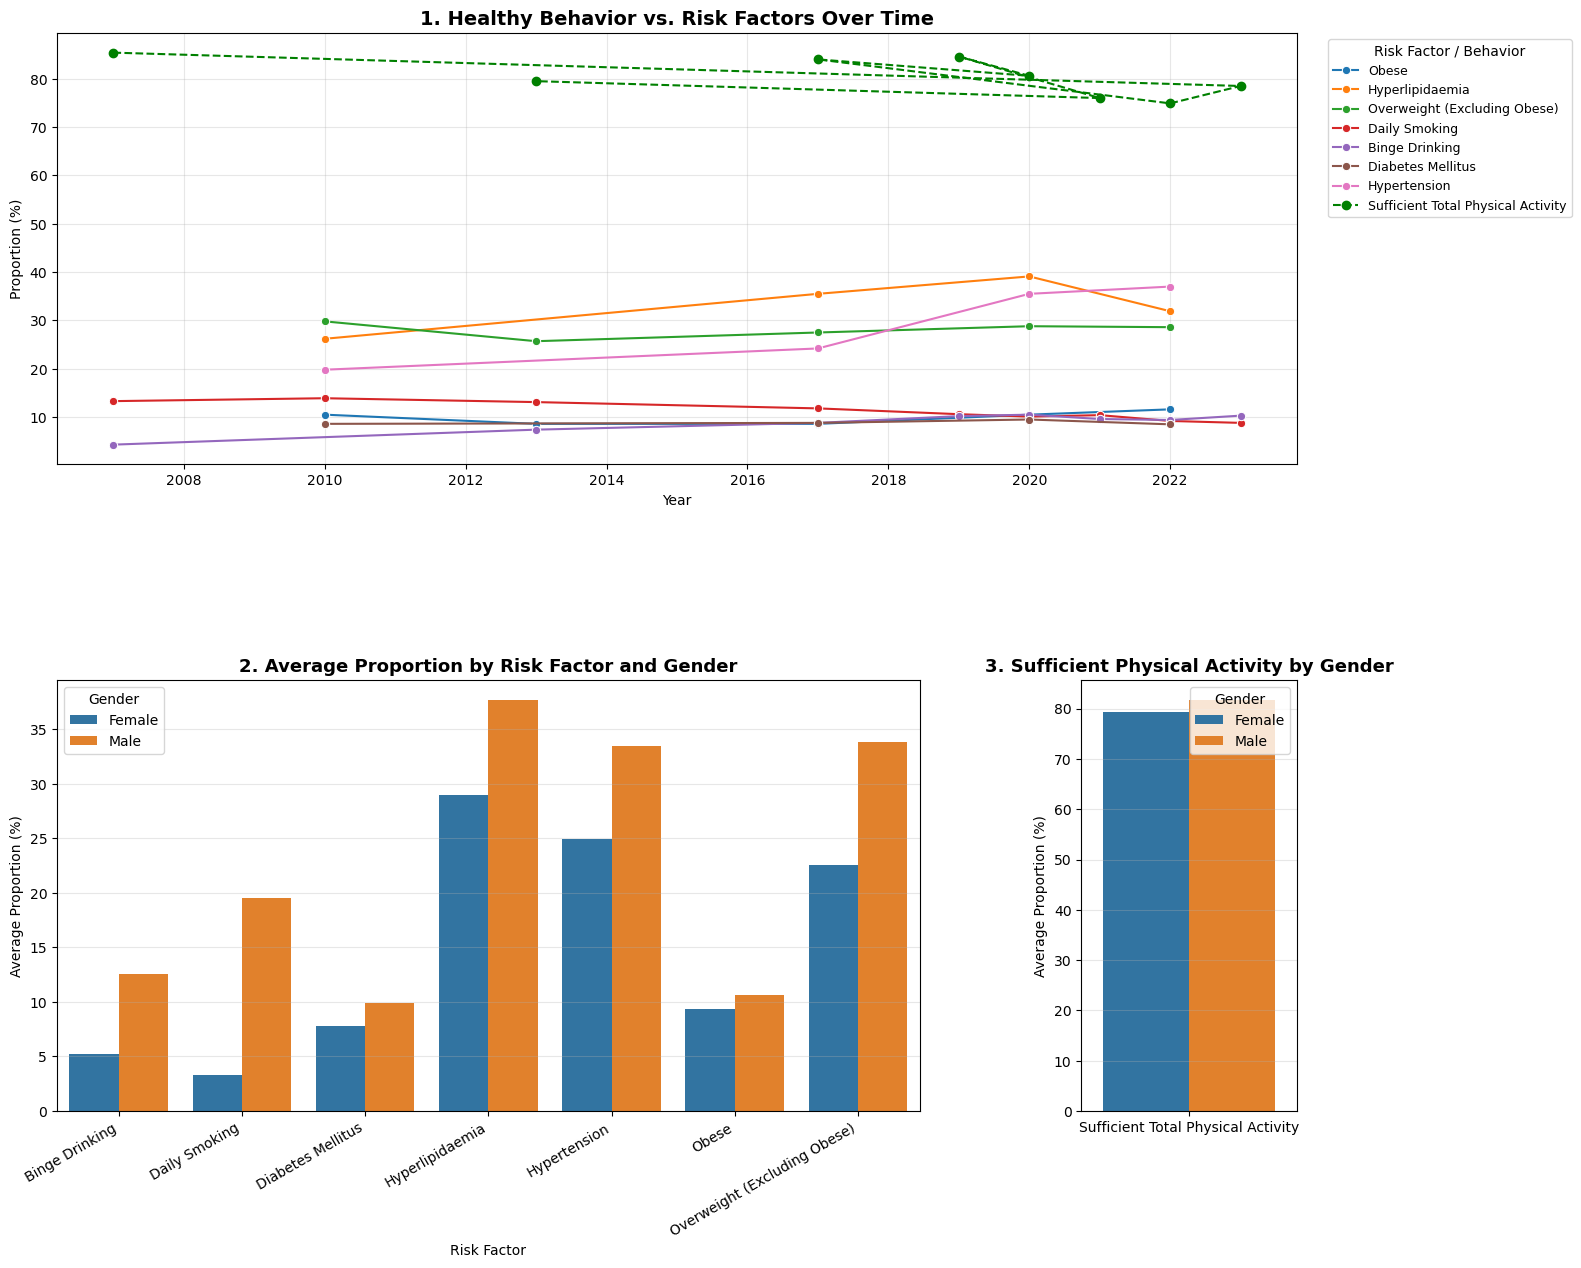

In [131]:
fig = plt.figure(figsize=(16, 14))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], width_ratios=[4, 1], hspace=0.5, wspace=0.3)

# Chart 1: Healthy Behavior vs Risk Factors Over Time
# As Sufficient Total Physical Activity is a healthy behaviour versus the other risk factors, it is worth investigating whether physical activity is able to offset the rising trend of risk factors
ax0 = fig.add_subplot(gs[0, :])

sns.lineplot(
    data=total_df[total_df['Risk Factor'].isin(risk_factors)],
    x='Year',
    y='Proportion',
    hue='Risk Factor',
    marker='o',
    ax=ax0
)

healthy_df = total_df[total_df['Risk Factor'] == 'Sufficient Total Physical Activity']
ax0.plot(
    healthy_df['Year'],
    healthy_df['Proportion'],
    label='Sufficient Total Physical Activity',
    color='green',
    linestyle='--',
    marker='o'
)

ax0.set_title('1. Healthy Behavior vs. Risk Factors Over Time', fontsize=14, fontweight='bold')
ax0.set_xlabel('Year')
ax0.set_ylabel('Proportion (%)')
ax0.legend(title='Risk Factor / Behavior', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax0.xaxis.set_major_locator(MaxNLocator(integer=True))
ax0.grid(alpha=0.3)

# Chart 2: Average Proportion by Risk Factor and Gender
# Uncover gender differences between risk factors
ax1 = fig.add_subplot(gs[1, 0])

sns.barplot(
    data=risk_only,
    x='Risk Factor',
    y='Proportion',
    hue='Gender Category',
    ax=ax1
)
ax1.set_title('2. Average Proportion by Risk Factor and Gender', fontsize=13, fontweight='bold')
ax1.set_xlabel('Risk Factor')
ax1.set_ylabel('Average Proportion (%)')
ax1.tick_params(axis='x', rotation=30)
for label in ax1.get_xticklabels():
    label.set_ha('right')
ax1.legend(title='Gender')
ax1.grid(alpha=0.3, axis='y')

# Chart 3: Sufficient Physical Activity by Gender
# Investigate gender differences in Sufficient Physical Activity, and its subsequent relationship with risk factors
ax2 = fig.add_subplot(gs[1, 1])

sns.barplot(
    data=activity_only,
    x='Risk Factor',
    y='Proportion',
    hue='Gender Category',
    ax=ax2
)
ax2.set_title('3. Sufficient Physical Activity by Gender', fontsize=13, fontweight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('Average Proportion (%)')
ax2.tick_params(axis='x', rotation=0)
ax2.legend(title='Gender')
ax2.grid(alpha=0.3, axis='y')

plt.show()

**Healthy Behavior vs Risk Factors**: Sufficient Total Physical Activity has had a steady decline, with several risk factors rising over the years. Physical Activity fell from 85.4% in 2007 to 78.5% in 2023. This shows that physical activity levels are not sufficient enough to offset the rising proportion of risk factors.

Among risk factors, hypertension shows the sharpest increase in prportion from 19.8% in 2010 to 37% in 2022. This increase outpaces any other risk factor. Hypertension and hyperlipidaemia are closely related co-morbodities and this is reflected in the increasing proportions over the years.

Notably, Binge Drinking has more than doubled from 4.3% in 2007 to 10.3% in 2023. Alongside hypertension and hyperlipidaemia, Binge Drinking is a rising concern.

On a more positive note, Daily Smoking sees a sustained decline from 13.3% in 2007 to 8.8% in 2023. This likely reflects the sustained effort in anti-smoking campaigns and policies over the period.

**Gender vs Risk Factors**: Males have consistently higher rates across every risk factor.

Among risk factors, behavioral ones show the largest gender gaps while biological ones are much closer. Daily Smoking has the largest gap, with Males (19.51%) being 6 times higher than Females (3.3%). Obesity and Diabetes Mellitus are more balanced between genders, with Males only having slightly higher proportions. This reflects how Males also have different lifestyle behaviors that contribute significantly to these risk factors.

Overweight (Excluding Obese) shows Males at 33.8%, which is around 1.5 times higher than Females at 22.54%. This is a meaningful distinction when compared to obesity because Males are much more represented in the overweight category.

**Physical Activity vs Gender**: Interestingly, while Males have higher Sufficient Physical Activity than Females, it is insufficient to offset the higher risk factor burden in Males. This strongly suggests that other lifestyle drivers are more influential.